# <h1 style="text-align: center;"><strong> Checkpoint 4 – Limites, Desempenho de APIs e Streamlit</strong></h1>

<center> <strong>Integrantes</strong> : Livia Laur, Lara Beatriz, Gustavo Inoue, Rafael Dias e Luca Baccari </center>

### Objetivo
- Desenvolver um modelo matemático e computacional para analisar o comportamento
do tempo de resposta de uma API à medida que a carga de requisições aumenta.
- Utilizar limites para investigar regiões críticas.
- Implementar a análise em Python
- Disponibilizar uma aplicação interativa em Streamlit que transforme o modelo em uma ferramenta de exploração e apoio à decisão.


### Pré-requisitos e setup
- Python 3.10+ com Jupyter.
- Pacotes necessários:

In [ ]:
!pip install pandas sympy matplotlib streamlit

### Importações

In [2]:
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np
import streamlit as st

### Construção e leitura do DataFrame

In [3]:
df = pd.DataFrame({
    'requisicoes_por_segundo': [10, 20, 30, 35, 40, 45, 48],
    'tempo_medio_resposta': [25, 33, 50, 67, 100, 200, 500]
})

In [4]:
display(df)

,requisicoes_por_segundo,tempo_medio_resposta
0,10,25
1,20,33
2,30,50
3,35,67
4,40,100
5,45,200
6,48,500


# Construção do modelo matemático

#### Função matemática representante

$$
\lim_{x \to 50^-} f(x) = +\infty
$$

significa que o tempo de resposta cresce sem limite conforme a carga se aproxima de 50req/s.

$x \to 50^-$ (limite lateral pela esquerda: aproximo de $50$ vindo por valores menores que $50$)

|                   |                                               |
| ------------------------- | ----------------------------------------------------------- |
| Variável independente     | quantidade de requisições por segundo                       |
| Variável dependente       | tempo médio de resposta                                     |
| Unidade da independente   | req/s                                                       |
| Unidade da dependente     | ms                                                          |
| Domínio matemático        |  $(-\infty, 50) \cup (50, +\infty)$                     |
| Domínio válido no sistema | $0 \le x < 50$ |


A única restrição da função racional é $x$ ser qualquer número real diferente de 50. Mas, para ser válido no sistema, o mínimo de requisições válidas é 0.

### Simulação do comportamento do sistema

In [5]:
# definindo x como número real + f(x)
x = sp.symbols("x", real=True)
f_x = 1000 / (50 - x)

cargas = [10, 20, 30, 40, 45, 48, 49, 49.5, 49.9]

f_num = sp.lambdify(x, f_x, "numpy")
tempos_ms = [f_num(c) for c in cargas]
tempos_s = [t / 1000 for t in tempos_ms]

df_simulacao = pd.DataFrame(
    {
        "Carga (req/s)": cargas,
        "Tempo Previsto (ms)": [round(t, 2) for t in tempos_ms],
        "Tempo Previsto (s)": [round(t, 2) for t in tempos_s],
    }
)

display(df_simulacao)

,Carga (req/s),Tempo Previsto (ms),Tempo Previsto (s)
0,10.0,25.00,0.03
1,20.0,33.33,0.03
2,30.0,50.00,0.05
3,40.0,100.00,0.10
4,45.0,200.00,0.20
5,48.0,500.00,0.50
6,49.0,1000.00,1.00
7,49.5,2000.00,2.00
8,49.9,10000.00,10.00


Os valores numéricos mostram um crescimento não linear acentuado (exponencial de fila) no tempo de resposta à medida que a carga passa de $40\text{ req/s}$.

- Entre $10$ e $40\text{ req/s}$, o aumento do tempo de resposta é suave, variando apenas $75\text{ ms}$ (de $25\text{ ms}$ para $100\text{ ms}$).

- A partir de $45\text{ req/s}$, a degradação se acelera. Quando a carga salta de $48$ para $49,9\text{ req/s}$ (uma variação de apenas $1,9\text{ req/s}$), o tempo de resposta dispara de $500\text{ ms}$ ($0,5\text{s}$) para $10.000\text{ ms}$ ($10\text{ segundos}$).

#### Comparando os valores de k em diferentes níveis de carga

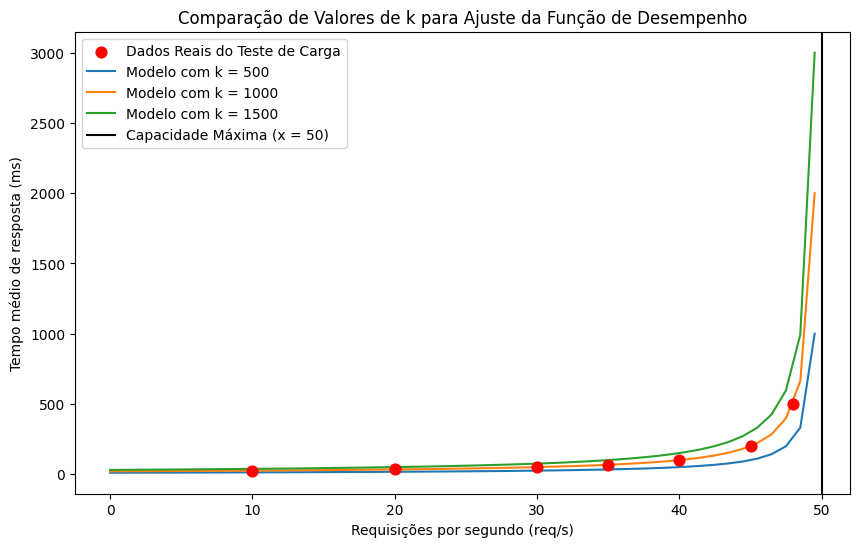

In [6]:
x_dados = df['requisicoes_por_segundo']
y_dados = df['tempo_medio_resposta']

# gera uma sequência de números com intervalos iguais dentro do range
# definindo o máximo como quase 50, por termos de performance
x_curva = np.linspace(0, 49.5)

# testando na mão diferentes k valores
k_valores = [500, 1000, 1500]

plt.figure(figsize=(10, 6))
plt.scatter(x_dados, y_dados, color="red", s=60, zorder=5, label="Dados Reais do Teste de Carga")

for k in k_valores:
    y_curva = k / (50 - x_curva)
    plt.plot(x_curva, y_curva, label=f"Modelo com k = {k}")

# assíntota vertical em x = 50
plt.axvline(x=50, color="black", label="Capacidade Máxima (x = 50)")

plt.title("Comparação de Valores de k para Ajuste da Função de Desempenho")
plt.xlabel("Requisições por segundo (req/s)")
plt.ylabel("Tempo médio de resposta (ms)")
plt.legend()
plt.show()

#### Observando o gráfico, vimos que os dados reais do DF estão exatamente sobre a curva do modelo com k = 1000, calibrando a função

- Ou seja, a função **racional** que descreve o comportamento observado no teste de carga é:
$$f(x) = \frac{1000}{50 - x}$$

  - A função acima representa o efeito de enfileiramento, ou seja, a medida que a carga aumenta, o tempo de espera não cresce de forma linear, mas de forma **assintótica**

- O ponto crítico a ser investigado é $x = 50\text{ req/s}$, analisado por meio do limite lateral pela esquerda:$$\lim_{x \to 50^-} \frac{1000}{50 - x} = +\infty$$

- O ponto $x = 50\text{ req/s}$ representa a assíntota vertical de saturação total da infraestrutura. Na **Engenharia de Software**, este limite tendendo ao infinito indica a formação de filas infinitas de requisições, esgotamento do pool de threads/conexões do servidor e estouro da memória (OOM) ou timeouts generalizados na API.

**A capacidade estimada de $50\text{ req/s}$ representa a capacidade teórica máxima de esgotamento e não uma capacidade segura de operação.**

Pelo modelo construído, $f(50)$ gera uma indeterminação/divisão por zero (o ponto não pertence ao domínio da função). Além disso, como $\lim_{x \to 50^-} f(x) = +\infty$, qualquer carga muito próxima de $50$ (como $49{,}9\text{ req/s}$) resultará em tempos de resposta inviáveis (superiores a $100.000\text{ ms}$ ou $100\text{s}$), fazendo com que as requisições sofram timeout muito antes de o sistema processar exatamente $50\text{ req/s}$.


# Análise matemática utilizando limites

### 1 - Limite lateral pela esquerda

In [7]:
limite_critico = sp.limit(f_x, x, 50, dir='-')
print("Lim x→50⁻ 1000/(50-x):", limite_critico)

Lim x→50⁻ 1000/(50-x): oo


$$\lim_{x \to 50^-} \frac{1000}{50 - x} = \frac{1000}{0^+} = +\infty$$

O resultado é um limite infinito positivo. Conforme a quantidade de requisições se aproxima de 50 req/s, o tempo médio de resposta cresce de maneira desproporcional e sem limite.

### 2 - Limite no infinito

In [8]:
limite_infinito = sp.limit(f_x, x, sp.oo)
print("Lim x→∞ 1000/(50-x):", limite_infinito)

Lim x→∞ 1000/(50-x): 0


$$\lim_{x \to +\infty} \frac{1000}{50 - x} = \frac{1000}{-\infty} = 0$$

O resultado é um limite finito igual a 0. A medida em que x cresce além de 50, a função retorna valores negativos aproximando de zero

### Comportamento da função

- Possui uma **descontinuidade** de salto infinito no ponto x = 50
- Existe uma **assíntota vertical** na reta x = 50, em que a curva do gráfico se aproxima da linha vertical sem tocá-la, tendendo ao infinito
- Existe uma assíntota horizontal na reta y = 0, referente ao comportamento do limite no infinito

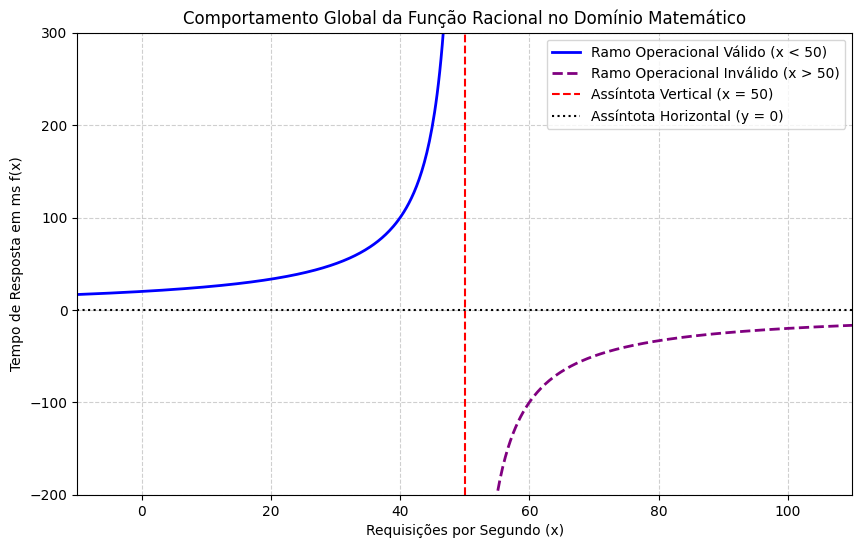

In [9]:
x_ramo1 = np.linspace(-10, 49.5, 300)
y_ramo1 = 1000 / (50 - x_ramo1)

x_ramo2 = np.linspace(50.5, 110, 300)
y_ramo2 = 1000 / (50 - x_ramo2)

plt.figure(figsize=(10, 6))

plt.plot(
    x_ramo1,
    y_ramo1,
    color="blue",
    linewidth=2,
    label="Ramo Operacional Válido (x < 50)",
)
plt.plot(
    x_ramo2,
    y_ramo2,
    color="purple",
    linestyle="--",
    linewidth=2,
    label="Ramo Operacional Inválido (x > 50)",
)

plt.axvline(
    x=50,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Assíntota Vertical (x = 50)",
)
plt.axhline(
    y=0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="Assíntota Horizontal (y = 0)",
)

plt.title(
    "Comportamento Global da Função Racional no Domínio Matemático", fontsize=12
)
plt.xlabel("Requisições por Segundo (x)", fontsize=10)
plt.ylabel("Tempo de Resposta em ms f(x)", fontsize=10)
plt.ylim(-200, 300)
plt.xlim(-10, 110)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [10]:
# ao substituir x = 0 na função:
f_0 = 1000 / (50 - 0)
print("f(0) = ", f_0)

f(0) =  20.0


$$f(0) = \frac{1000}{50 - 0} = \frac{1000}{50} = 20\text{ ms}$$

a API ainda leva $20\text{ ms}$ para processar o código, consultar o banco de dados e devolver a resposta. Ou seja, o tempo de resposta nunca será menor do que **$20\text{ ms}$** no domínio operacional ($0 \le x < 50$).

Por mais que os cálculos definidos estejam **matematicamente válidos**, de maneira **operacinal**, só é válida a região em que 0 <= x < 50 e f(x) >= 20ms

### Operação da API

- A assíntota em x=50req/s prova que o hardware atual atinge o colapso total próximo desse volume
-  Para manter acordos de nível de serviço (SLA) aceitáveis, a API deve operar a no máximo 40req/s

Em um modelo de **desempenho de software**, uma **assíntota vertical** representa o ponto de colapso absoluto da infraestrutura (ponto de saturação por esgotamento de recursos). Na prática, o sistema para de responder (trava), derruba as conexões ativas e resulta em indisponibilidade total da API.

# Aplicação interativa em Streamlit

In [11]:
%%writefile app.py

import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np
import streamlit as st

st.set_page_config(
    page_title="Análise de Desempenho da API",
    page_icon="⚡",
    layout="wide"
)

# a) Título, descrição do problema e identificação das variáveis
st.title("⚡ Simulação e Análise de Desempenho da API")
st.markdown("---")

st.markdown("""
### Contexto do Problema
Esta aplicação utiliza um modelo matemático para prever o tempo médio de resposta de uma API sob diferentes níveis de carga.
Conforme a taxa de requisições aumenta e se aproxima da capacidade máxima de processamento da infraestrutura (50 req/s),
o tempo de resposta cresce assintoticamente, podendo comprometer a operação e violar os acordos de nível de serviço (SLA).

**Variáveis do Modelo:**
* **Variável Independente ($x$):** Quantidade de requisições por segundo (unidade: `req/s`).
* **Variável Dependente ($f(x)$):** Tempo médio de resposta da API (unidade: `ms`).
* **Função do Modelo:** $f(x) = \\frac{1000}{50 - x}$.
""")

st.sidebar.header("⚙️ Painel de Controle de Carga")

# b) Controle interativo para informar a quantidade de requisições por segundo
carga = st.sidebar.slider(
    "Selecione a carga de requisições (req/s):",
    min_value=0.0,
    max_value=49.9,
    value=30.0,
    step=0.1,
    help="Escolha um valor dentro do domínio operacional seguro (0 a 49.9 req/s)."
)

# c) Cálculo do tempo de resposta previsto
if carga < 50:
    tempo_resposta = 1000 / (50 - carga)
else:
    tempo_resposta = float('inf')

st.subheader("📊 Diagnóstico da Operação")
col1, col2 = st.columns(2)

with col1:
    st.metric(
        label="Carga Selecionada",
        value=f"{carga:.1f} req/s"
    )

with col2:
    if tempo_resposta != float('inf'):
        st.metric(
            label="Tempo de Resposta Previsto",
            value=f"{tempo_resposta:.2f} ms",
            delta=f"{(tempo_resposta - 20):.2f} ms acima da latência base"
        )
    else:
        st.metric(
            label="Tempo de Resposta Previsto",
            value="∞ ms (Saturação Total)"
        )

# f) Apresentação de referência de desempenho (SLA de Latência)
SLA_LIMITE_MS = 200.0

st.markdown("---")
# e) Indicação visual / mensagem de alerta referente à região crítica e SLA
if carga >= 45.0:
    st.error(f"🔴 **CRÍTICO - FORA DO SLA DE OPERAÇÃO!** Tempo de resposta de **{tempo_resposta:.2f} ms** excede significativamente o limite seguro de SLA ({SLA_LIMITE_MS} ms). Risco iminente de timeout e indisponibilidade do sistema.")
elif carga >= 40.0:
    st.warning(f"⚠️ **ATENÇÃO - REGIÃO CRÍTICA!** Carga no limiar de saturação ({carga:.1f} req/s). Tempo de resposta ({tempo_resposta:.2f} ms) aproxima-se do limite tolerável de SLA ({SLA_LIMITE_MS} ms).")
else:
    st.success(f"✅ **OPERAÇÃO NORMAL - DENTRO DO SLA.** O tempo de resposta ({tempo_resposta:.2f} ms) está abaixo da meta aceitável ({SLA_LIMITE_MS} ms).")

# d) Gráfico da função contendo a carga selecionada, a região crítica e a assíntota
x_vals = np.linspace(0, 49.8, 500)
y_vals = 1000 / (50 - x_vals)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_vals, y_vals, label=r"$f(x) = \frac{1000}{50-x}$", color="blue", linewidth=2)
ax.scatter([carga], [tempo_resposta], color="red", s=100, zorder=5, label=f"Carga Selecionada: {carga:.1f} req/s ({tempo_resposta:.1f} ms)")
ax.axhline(y=SLA_LIMITE_MS, color="green", linestyle="--", linewidth=1.5, label=f"Meta SLA de Latência ({SLA_LIMITE_MS} ms)")
ax.axvspan(40, 50, color="orange", alpha=0.2, label="Região Crítica (Risco de Saturação)")
ax.axvline(x=50, color="red", linestyle=":", linewidth=2, label="Assíntota Vertical: Saturação (x = 50 req/s)")
ax.set_title("Comportamento do Tempo de Resposta vs. Carga de Requisições", fontsize=12)
ax.set_xlabel("Requisições por Segundo (req/s)", fontsize=10)
ax.set_ylabel("Tempo Médio de Resposta (ms)", fontsize=10)
ax.set_ylim(0, 600)
ax.set_xlim(0, 52)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left")

st.pyplot(fig)

Overwriting app.py


In [12]:
# Para executá-la localmente:
!streamlit run app.py

2026-08-16 11:56:28.163 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.0.211:8501

  Help agents write better Streamlit apps?
  Install the official Streamlit skills by running streamlit skills in your terminal.

  Stopping...
^C
  Stopping...


A aplicação converte cálculos abstratos de limites em uma ferramenta prática de tomada de decisão técnica por meio de três pilares:
- Simulação Direta de SLA (Acordo de Nível de Serviço): permite testar volumes reais de tráfego e verificar instantaneamente se a API atende aos limites de tempo de resposta.
- Margem de Segurança Clara: utiliza alertas visuais para demonstrar que $50\text{ req/s}$ é o ponto de colapso, ajudando a configurar Rate Limiting e Auto-scaling em faixas operacionais seguras ($35\text{ a }40\text{ req/s}$).
- Justificativa para Investimentos: exibe o comportamento assintótico em gráficos intuitivos, embasando decisões para a equipe sobre uso de cache, balanceamento de carga ou expansão de infraestrutura.

O modelo apresenta limitações importantes ao isolar o tempo de resposta como uma consequência exclusiva da taxa de requisições por segundo, ignorando a variação de complexidade entre diferentes chamadas na API. Ele também trata a capacidade como um limite estático, desconsiderando variações dinâmicas no consumo de CPU, memória e rede, além de simplificar o enfileiramento real, que possui natureza probabilística e sujeira a picos instantâneos. 

Para aprimorar a análise, seria fundamental coletar métricas detalhadas de hardware durante os testes, mapear o perfil do tráfego por tipo de rota, analisar logs de erros HTTP e timeouts, e utilizar percentis de latência (como P95 e P99) em vez de apenas o tempo médio.